In [37]:
import glob,numpy as np,os
def keep_best_per_cell_fast(XH_f,nbest=20,brightness_index=-6,cell_index=-4,region_index=-5):
   
    ###sort molecules by brightness and keep only within cells (CELLs>0)
    XH_f_ = XH_f.copy()
    H = XH_f_[:,brightness_index] #brightness
    XH_f_ = XH_f[np.argsort(H)]
    CELLs = XH_f_[:,cell_index].astype(int) #cell index
    keep = CELLs>0
    XH_f_ = XH_f_[keep]
    
    
    #################################
    CELLs = XH_f_[:,cell_index] #cell index
    H = XH_f_[:,brightness_index] #brightness
    ### find index combining cell id an redout id
    Rs = XH_f_[:,region_index].astype(int) #readout
    
    
    
    
    cellsu = np.unique(CELLs)
    Rsu = np.unique(Rs)
    MR = np.max(Rsu)+1
    mix_index = CELLs*MR+Rs ### unique index combining cell and readout info
    
    #### find the inverse and prealocate space that you fill cyclically
    miu,rinv = np.unique(mix_index,return_inverse=True)
    #miu_,cts_ = np.unique(mix_index,return_counts=True)
    XH_f_pruned = np.zeros([len(miu),nbest,XH_f.shape[1]],dtype=XH_f.dtype)+np.nan
    ind_best = np.argsort(np.argsort(rinv))%nbest
    #import numpy as np
    from collections import Counter
    
    def create_counter_array(A):
        counter = Counter()
        B = np.zeros_like(A)
        
        for i, num in enumerate(A):
            B[i] = counter[num]
            counter[num] += 1
        
        return B
    ind_best = create_counter_array(rinv)%nbest
    XH_f_pruned[rinv,ind_best,:]=XH_f_######
    XH_f_pruned = XH_f_pruned.reshape([-1,XH_f_pruned.shape[-1]])
    good = ~np.isnan(XH_f_pruned)[:,0]
    XH_f_pruned = XH_f_pruned[good]
    return XH_f_pruned
import matplotlib.pylab as plt

In [38]:
# dic_th = {('D110',1):8.5,('D119',1):10.5,('D104',1):11.5,('D114',1):10.75,('D120',1):11,('D108',1):10.75,
#           ('D110',0):8.5,('D119',0):11,('D104',0):10,('D114',0):11,('D120',0):10,('D108',0):10.5}

In [39]:
dic_th = {('D110', 1): 8.18874215580711, ('D119', 1): 9.559191420385371, ('D104', 1): 10.091478843014036, ('D114', 1): 9.961322077569395, ('D120', 1): 9.731701501584798, ('D108', 1): 9.886285014513302, ('D110', 0): 9.297593531571685, ('D119', 0): 12.030497798055707, ('D104', 0): 11.502463319775378, ('D114', 0): 12.47202251110717, ('D120', 0): 11.223944756805565, ('D108', 0): 11.795240061806638}

In [40]:
### map the day 80 cells
#glob.glob(r'\\merfish8\merfish8v1\20230801D104Myh67d80\AnalysisDeconvolveCG\IntronsBB\*--intronsMyh6Myh7.npz') #D104: D80 WT Kiwi

In [5]:
dic_tags = {'D104':r'\\merfish8\merfish8v1\20230801D104Myh67d80\AnalysisDeconvolveCG\IntronsBB\*--intronsMyh6Myh7.npz', #D104: D80 WT Kiwi
'D110':r'\\merfish10.ucsd.edu\volume1\20231121D110Myh67d15WT\AnalysisDeconvolveBBIntronD110\IntronsKY\*--intronsMyh6Myh7.npz', #D110: D15 WT Kiwi
'D119':r'\\172.16.200.26\merfish22v2\2024_9_25_D119_analysis\Intron\IntronFinal\*--intronsMyh6Myh7.npz', #D119: D15 WT Plum
'D114':r'\\172.16.200.26\merfish22v2\2024_9_4_D114_analysis\Intron\IntronFinal\*--intronsMyh6Myh7.npz', #D114: D15 Myh6P KO Plum
'D120':r'\\merfish11.ucsd.edu\Public\2024_12_11_D120_Myh7p_d5KO_d80\DNA_singleCy5_AnalysisKY\Intron\IntronFinal\*--intronsMyh6Myh7.npz', #D120: D80 delta5 KO Lemon
'D108':r'\\merfish12.ucsd.edu\Public\20231231_D108_Myh67_d15E12KO\Analysis_KY\Intron\IntronFinal\*--intronsMyh6Myh7.npz'} #D108: D15 E1/2 KO Lemon

In [6]:

#print("Thresholds for Myh6,7 introns:",key,(th6,th7))

Thresholds for Myh7,6 introns: D104 (12.75, 11.721965521719671)


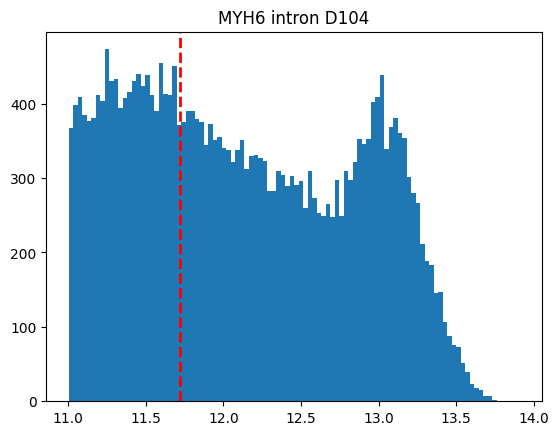

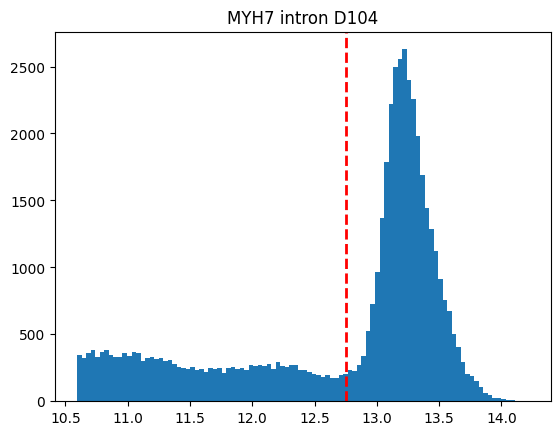

In [7]:
key = 'D104'
Xh_Myh6_fs,Xh_Myh7_fs=[],[]
tag = dic_tags[key]
fls = glob.glob(tag)
for save_flf in fls:
    Xh_Myh7_f = np.load(save_flf)['Xh_Myh7_f']#,Xh_Myh7_f=Xh_Myh7_f,Xh_Myh6_f=Xh_Myh6_f)
    Xh_Myh6_f = np.load(save_flf)['Xh_Myh6_f']
    Xh_Myh6_fs.append(Xh_Myh6_f)
    Xh_Myh7_fs.append(Xh_Myh7_f)
Xh_Myh6_fs = np.concatenate(Xh_Myh6_fs)
Xh_Myh7_fs = np.concatenate(Xh_Myh7_fs)


Xh_Myh6_fs_ = keep_best_per_cell_fast(Xh_Myh6_fs,nbest=2,brightness_index=-6,cell_index=-4,region_index=-5)
Xh_Myh7_fs_ = keep_best_per_cell_fast(Xh_Myh7_fs,nbest=2,brightness_index=-6,cell_index=-4,region_index=-5)

#th7,th6 = 12.-dic_th[('D119',1)]+dic_th[(key,1)],12.-dic_th[('D119',0)]+dic_th[(key,0)]
th7,th6 =12.75-dic_th[('D104',1)]+dic_th[(key,1)],12.25-dic_th[('D119',0)]+dic_th[(key,0)]
print("Thresholds for Myh7,6 introns:",key,(th7,th6))

plt.figure()
plt.title('MYH6 intron '+key)
plt.hist(np.log(Xh_Myh6_fs_[:,-6]),bins=100);
plt.axvline(th6, color='red', linestyle='--', linewidth=2)
plt.figure()
plt.title('MYH7 intron '+key)
plt.hist(np.log(Xh_Myh7_fs_[:,-6]),bins=100);
plt.axvline(th7, color='red', linestyle='--', linewidth=2)

In [8]:
dic_th_volm = {'D104': 13359.726829661873, 'D110': 6310.688108089024, 'D119': 6310.688108089024, 'D114': 13359.726829661873, 'D120': 13359.726829661873, 'D108': 13359.726829661873}

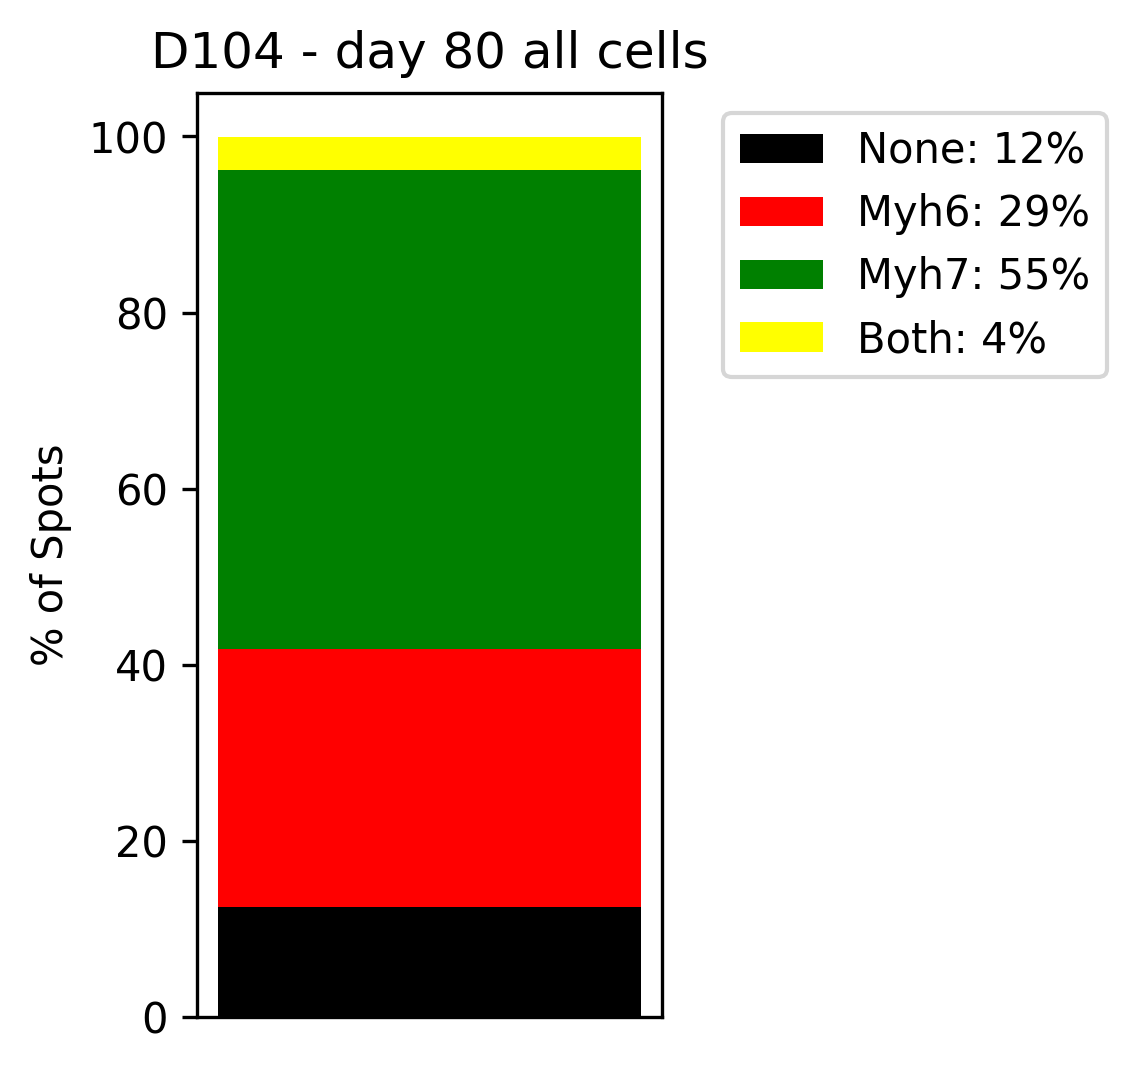

In [12]:
Xh_Myh6_fs__ = Xh_Myh6_fs_[Xh_Myh6_fs_[:,-6]>np.exp(th6)]
Xh_Myh7_fs__ = Xh_Myh7_fs_[Xh_Myh7_fs_[:,-6]>np.exp(th7)]
cells6 = Xh_Myh6_fs__[:,-5]*10**5+Xh_Myh6_fs__[:,-4]
cells7 = Xh_Myh7_fs__[:,-5]*10**5+Xh_Myh7_fs__[:,-4]
fl_volm = r'C:\Users\Carlos\Desktop\Brightness_check'+os.sep+key+'_cells.npz'
volms = np.load(fl_volm)['volms']
cells_all = np.load(fl_volm)['cells']
th_vol = dic_th_volm[key]

ifovs_all = cells_all//10**5
ifovs_covered = np.unique(np.concatenate([Xh_Myh6_fs[:,-5],Xh_Myh7_fs[:,-5]])).astype(int)
cells_covered = np.unique(np.concatenate([Xh_Myh6_fs[:,-5]*10**5+Xh_Myh6_fs[:,-4],Xh_Myh7_fs[:,-5]*10**5+Xh_Myh7_fs[:,-4]])).astype(int)

keep_cells = cells_all[(volms>th_vol)&np.in1d(ifovs_all,ifovs_covered)]
keep_cells = cells_all[(volms>th_vol)&np.in1d(cells_all,cells_covered)]
keep6 = np.in1d(cells6,keep_cells)
keep7 = np.in1d(cells7,keep_cells)
cells6f =cells6[keep6]
cells7f =cells7[keep7]
Xh_Myh6_fs__f = Xh_Myh6_fs__[keep6]
Xh_Myh7_fs__f = Xh_Myh7_fs__[keep7]
from scipy.spatial import KDTree
dd,ii = KDTree(Xh_Myh6_fs__f[:,:3]).query(Xh_Myh7_fs__f[:,:3])
Xh_Myh7_fs__I = Xh_Myh7_fs__f[dd<2.5]
cellsI = cells7f[dd<2.5]


cellsu,ctsu = np.unique(cells6f,return_counts=True)
dic6 = dict(zip(cellsu.astype(np.uint64),ctsu))

cellsu,ctsu = np.unique(cells7f,return_counts=True)
dic7 = dict(zip(cellsu.astype(np.uint64),ctsu))

cellsu,ctsu = np.unique(cellsI,return_counts=True)
dicI = dict(zip(cellsu.astype(np.uint64),ctsu))
ctNone = 0
for c in keep_cells:
    if dic6.get(c,0)==2 or dic7.get(c,0)==2:
        pass
    else:
        ct = 2-(dic6.get(c,0)+dic7.get(c,0)-dicI.get(c,0))
        ctNone+=ct
none = ctNone

m67 = np.sum(list(dicI.values()))
m7O,m6O = np.sum(list(dic7.values()))-m67,np.sum(list(dic6.values()))-m67
total = none+m7O+m6O+m67


none_pct,is6_pct,is7_pct,both_pct = none/total*100,m6O/total*100,m7O/total*100,m67/total*100

import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(2, 4), dpi=300)
plt.title(key+" - day 80 all cells")
# Create the vertical bar plot with corresponding colors
ax.bar(1, none_pct, color='black', label=f'None: {none_pct:.0f}%')
ax.bar(1, is6_pct, bottom=none_pct, color='red', label=f'Myh6: {is6_pct:.0f}%')
ax.bar(1, is7_pct, bottom=none_pct + is6_pct, color='green', label=f'Myh7: {is7_pct:.0f}%')
ax.bar(1, both_pct, bottom=none_pct + is6_pct + is7_pct, color='yellow', label=f'Both: {both_pct:.0f}%')

# Set labels and title
ax.set_ylabel('% of Spots')

# Customize x-axis
ax.set_xticks([])
ax.set_xticklabels([])

# Display legend
ax.legend(loc='upper right', bbox_to_anchor=(2, 1))

# Show the plot
plt.show()

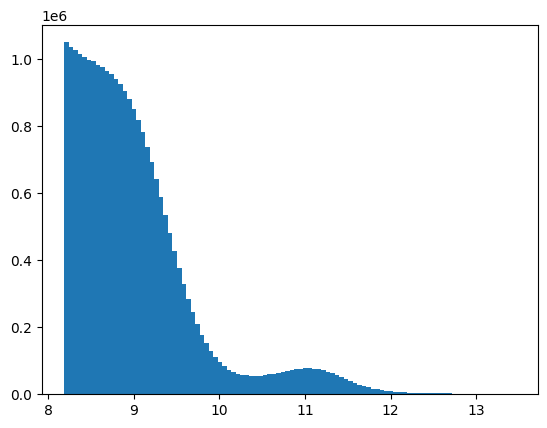

In [13]:
Xh_fs=[]
fls = glob.glob(r'\\merfish8\merfish8v1\20230801D104Myh67d80\AnalysisDeconvolveCG\ExonKY\*--exonMYL2.npz') #D104: D80 WT Kiwi
for save_flf in fls:
    Xh_f = np.load(save_flf)['Xh_f']
    Xh_fs.append(Xh_f)
Xh_fs = np.concatenate(Xh_fs)
Xh_fs_MYL2 = Xh_fs

#np.unique(cells_all,return_counts=True)
ifovs = Xh_fs_MYL2[:,-5]
icells = Xh_fs_MYL2[:,-5]*10**5+Xh_fs_MYL2[:,-4]
#Xh_fs_MYL2_ = keep_best_per_cell_fast(Xh_fs_MYL2,50)
plt.hist(np.log(Xh_fs_MYL2[:,-6]),bins=100);

In [14]:
import numpy as np
np.exp(10)

22026.465794806718

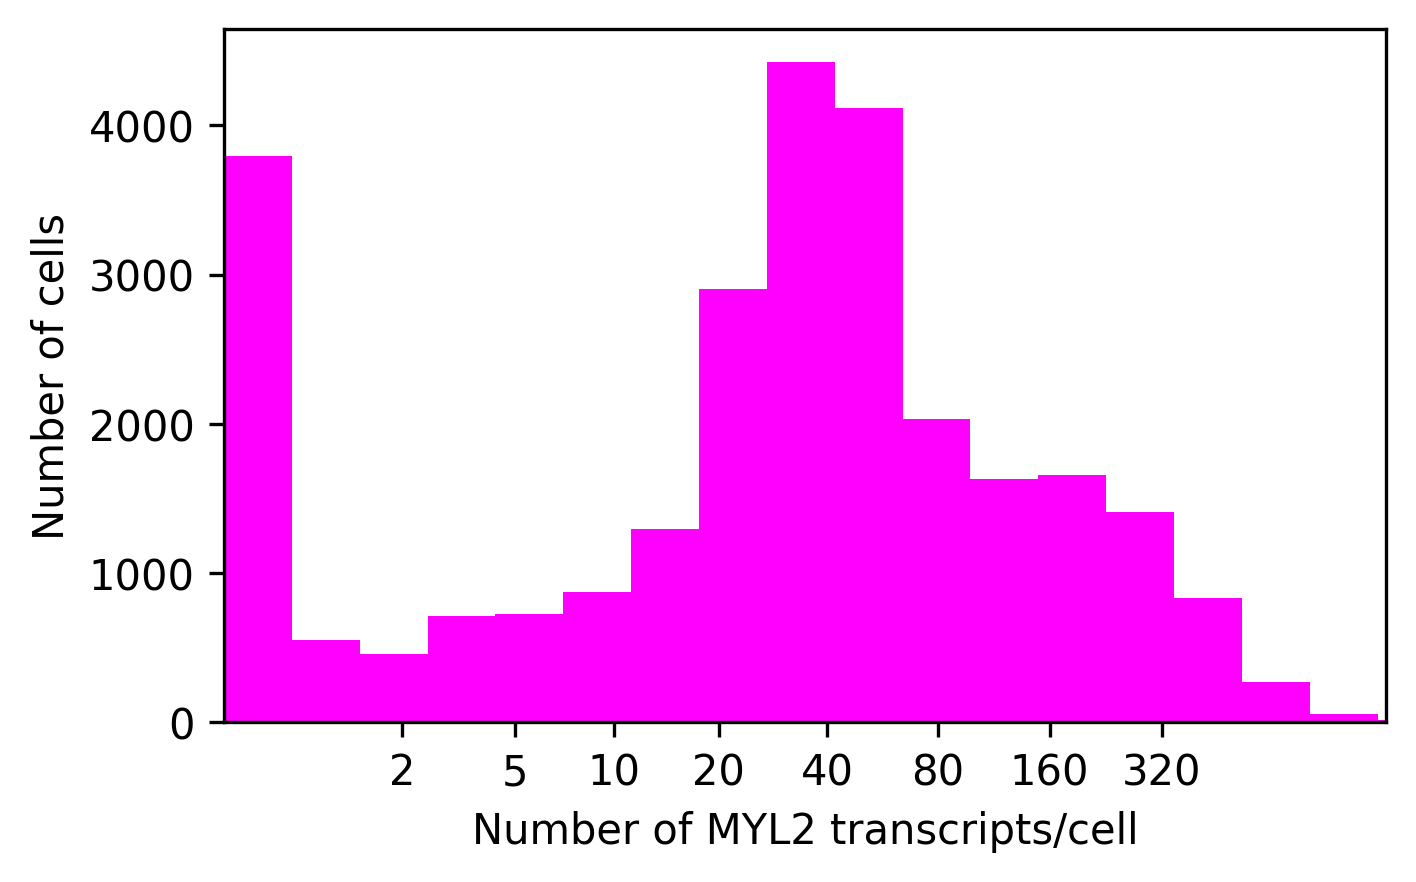

In [15]:
keep = Xh_fs_MYL2[:,-6]>np.exp(10.)
icellU,cts = np.unique(list(icells[keep])+list(cells_all[(volms>th_vol)]),return_counts=True)
cts = cts-1
plt.figure(figsize=(5,3),dpi=300)
plt.hist(np.log1p(cts),bins=20,color='magenta')
x = [2,5,10,20,40,80,160,320]
plt.xticks(np.log1p(x),x);
plt.xlim([0,np.log1p(320*4)])
#plt.axvline(np.log1p(15), color='k', linestyle='--', linewidth=2)
plt.xlabel("Number of MYL2 transcripts/cell")
plt.ylabel("Number of cells")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2_supp_D80.pdf", format='pdf', bbox_inches='tight', dpi=600)

plt.show()

In [16]:
np.mean(cts<15),np.mean(cts>=15)

(0.2786861629330836, 0.7213138370669163)

In [17]:
icells_CMS = icellU[cts>=15]

# Figure f

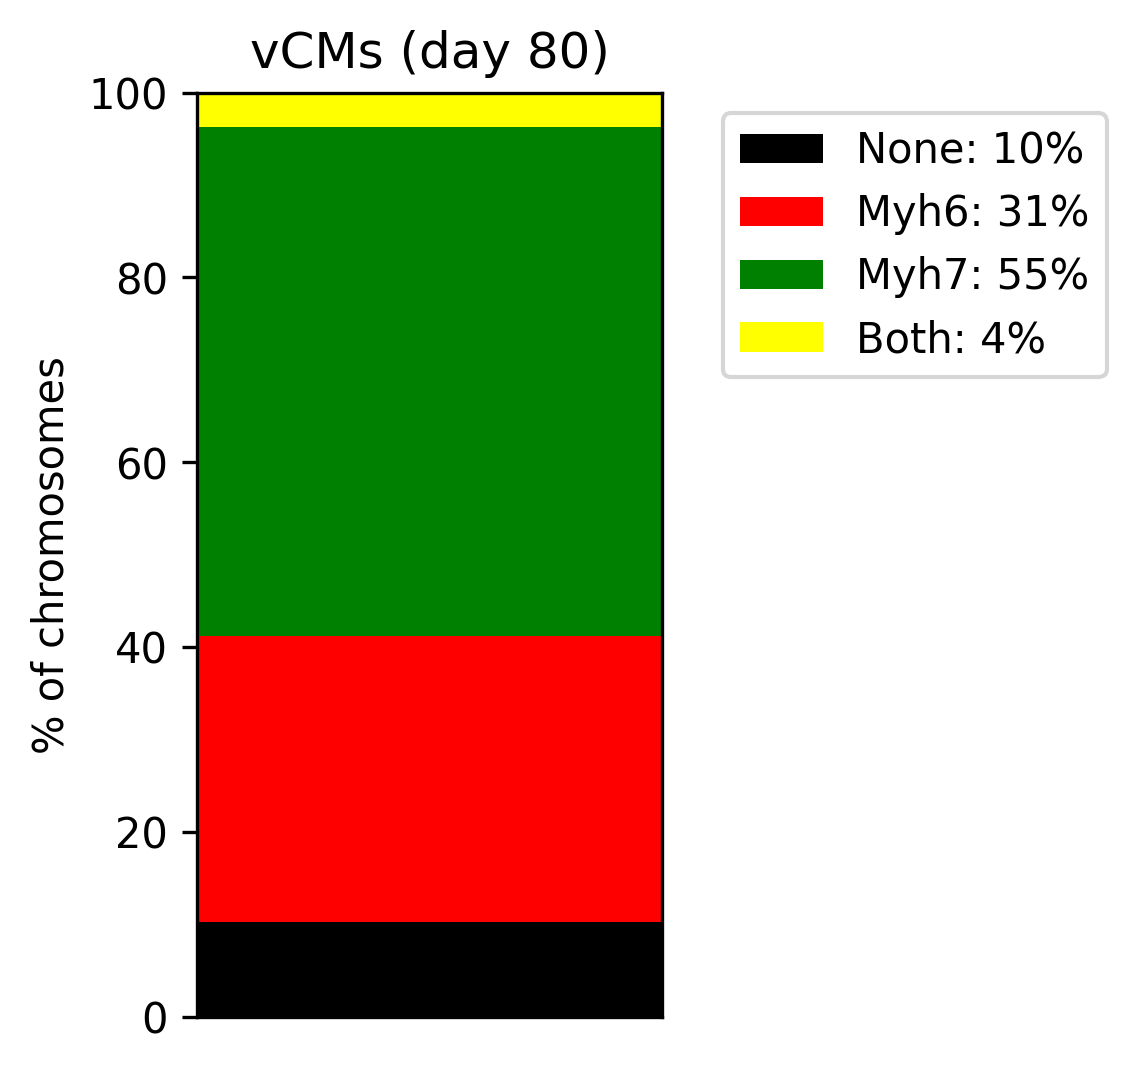

In [18]:
Xh_Myh6_fs__ = Xh_Myh6_fs_[Xh_Myh6_fs_[:,-6]>np.exp(th6)]
Xh_Myh7_fs__ = Xh_Myh7_fs_[Xh_Myh7_fs_[:,-6]>np.exp(th7)]
cells6 = Xh_Myh6_fs__[:,-5]*10**5+Xh_Myh6_fs__[:,-4]
cells7 = Xh_Myh7_fs__[:,-5]*10**5+Xh_Myh7_fs__[:,-4]
fl_volm = r'C:\Users\Carlos\Desktop\Brightness_check'+os.sep+key+'_cells.npz'
volms = np.load(fl_volm)['volms']
cells_all = np.load(fl_volm)['cells']
th_vol = dic_th_volm[key]

ifovs_all = cells_all//10**5
ifovs_covered = np.unique(np.concatenate([Xh_Myh6_fs[:,-5],Xh_Myh7_fs[:,-5]])).astype(int)
cells_covered = np.unique(np.concatenate([Xh_Myh6_fs[:,-5]*10**5+Xh_Myh6_fs[:,-4],Xh_Myh7_fs[:,-5]*10**5+Xh_Myh7_fs[:,-4]])).astype(int)

keep_cells = np.intersect1d(cells_all[(volms>th_vol)&np.in1d(ifovs_all,ifovs_covered)],icells_CMS)
keep_cells = np.intersect1d(cells_all[(volms>th_vol)&np.in1d(cells_all,cells_covered)],icells_CMS)
keep6 = np.in1d(cells6,keep_cells)
keep7 = np.in1d(cells7,keep_cells)
cells6f =cells6[keep6]
cells7f =cells7[keep7]
Xh_Myh6_fs__f = Xh_Myh6_fs__[keep6]
Xh_Myh7_fs__f = Xh_Myh7_fs__[keep7]
from scipy.spatial import KDTree
dd,ii = KDTree(Xh_Myh6_fs__f[:,:3]).query(Xh_Myh7_fs__f[:,:3])
Xh_Myh7_fs__I = Xh_Myh7_fs__f[dd<2.5]
cellsI = cells7f[dd<2.5]


cellsu,ctsu = np.unique(cells6f,return_counts=True)
dic6 = dict(zip(cellsu.astype(np.uint64),ctsu))

cellsu,ctsu = np.unique(cells7f,return_counts=True)
dic7 = dict(zip(cellsu.astype(np.uint64),ctsu))

cellsu,ctsu = np.unique(cellsI,return_counts=True)
dicI = dict(zip(cellsu.astype(np.uint64),ctsu))
ctNone = 0
for c in keep_cells:
    if dic6.get(c,0)==2 or dic7.get(c,0)==2:
        pass
    else:
        ct = 2-(dic6.get(c,0)+dic7.get(c,0)-dicI.get(c,0))
        ctNone+=ct
none = ctNone

m67 = np.sum(list(dicI.values()))
m7O,m6O = np.sum(list(dic7.values()))-m67,np.sum(list(dic6.values()))-m67
total = none+m7O+m6O+m67


none_pct,is6_pct,is7_pct,both_pct = none/total*100,m6O/total*100,m7O/total*100,m67/total*100

import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(2, 4), dpi=300)
plt.title("vCMs (day 80)")
# Create the vertical bar plot with corresponding colors
ax.bar(1, none_pct, color='black', label=f'None: {none_pct:.0f}%')
ax.bar(1, is6_pct, bottom=none_pct, color='red', label=f'Myh6: {is6_pct:.0f}%')
ax.bar(1, is7_pct, bottom=none_pct + is6_pct, color='green', label=f'Myh7: {is7_pct:.0f}%')
ax.bar(1, both_pct, bottom=none_pct + is6_pct + is7_pct, color='yellow', label=f'Both: {both_pct:.0f}%')

# Set labels and title
ax.set_ylabel('% of chromosomes')

# Customize x-axis
ax.set_xticks([])
ax.set_xticklabels([])

# Display legend
ax.legend(loc='upper right', bbox_to_anchor=(2, 1))
plt.ylim([0,100])
plt.xlim([1,1.2])
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2f_D80.pdf", format='pdf', bbox_inches='tight')
# Show the plot
plt.show()

In [ ]:
m6O

In [ ]:
m7O

In [ ]:
total

In [19]:
dic_Traces = {
    "D110":glob.glob(r'\\merfish10.ucsd.edu\volume1\20231121D110Myh67d15WT\AnalysisDeconvolveBBD110\best_per_cell_KY\*--__XHfs_finedrft_save.npz'),
    "D119":glob.glob(r'\\172.16.200.26\merfish22v2\2024_9_25_D119_analysis\best_per_cell_KY\*--__XHfs_finedrft_save.npz'),
    "D104":glob.glob(r'\\merfish8\merfish8v1\20230801D104Myh67d80\AnalysisDeconvolveCG\best_per_cell\*--__XHfs_finedrft_save.npz'),
    "D114":glob.glob(r'\\172.16.200.26\merfish22v2\2024_9_4_D114_analysis\best_per_cell\*--__XHfs_finedrft_save.npz'),
    "D108":glob.glob(r'\\merfish12.ucsd.edu\Public\20231231_D108_Myh67_d15E12KO\Analysis_KY\best_per_cell\*--__XHfs_finedrft_save.npz'),
    "D120":glob.glob(r'\\172.16.200.26\merfish22v2\2024_9_4_D114_analysis\best_per_cell\*--__XHfs_finedrft_save.npz'),
    "D118":glob.glob(r'\\merfish11.ucsd.edu\Public\20250113_D118_MYH67_WT_Day0\DNA_Analysis_KY\best_per_cell_KY\*--__XHfs_finedrft_save.npz')
}

In [20]:
dic_zxys_f = {}
from tqdm import tqdm
fls = dic_Traces['D104']
zxys_f=None
for fl in tqdm(fls):
    try:
        dic = np.load(fl)
        zxys_f_ = dic['zxys_f']
        scores_f_ = dic['scores_f'][...,np.newaxis]
        hs_f_ = dic['hs_f'][...,np.newaxis]
        cells_f_ = dic['cells_f']
        cells_f_ = np.repeat(cells_f_[:,np.newaxis],zxys_f_.shape[-2],axis=-1)[...,np.newaxis]
        zxys_f_ = np.concatenate([zxys_f_,hs_f_,scores_f_,cells_f_],axis=-1)
        
        zxys_f = zxys_f_ if zxys_f is None else np.concatenate([zxys_f,zxys_f_])
    except:
        print("Failed",fl)
    #dic['scores_f']
    #cells_f
np.nanmax(zxys_f.reshape(-1,3),axis=0)
cells_f = zxys_f[:,:,[-1]].astype(int)
ifovs = cells_f//10**5
shift = ifovs*np.array([[[0,225,0]]])
#shift = np.array([[0,225,0]])*((cells_f//10**5)[...,np.newaxis])[:,np.newaxis]
#zxys_f[:,:,:3]=zxys_f[:,:,:3]+shift
dic_zxys_f[key] = zxys_f

 51%|████████████████████████████████████████▋                                       | 153/301 [00:05<00:05, 25.99it/s]

Failed \\merfish8\merfish8v1\20230801D104Myh67d80\AnalysisDeconvolveCG\best_per_cell\Conv_zscan__149--__XHfs_finedrft_save.npz


100%|████████████████████████████████████████████████████████████████████████████████| 301/301 [00:12<00:00, 24.98it/s]


In [21]:
key = 'D104'
def get_zxys_fs(key):
    pix_sz=[0.3,0.1083333,0.1083333]
    XHM6 = dic_Myh6[key].copy()
    XHM6[:,:3] = XHM6[:,:3]*pix_sz
    XHM7 = dic_Myh7[key].copy()
    XHM7[:,:3] = XHM7[:,:3]*pix_sz
    
    zxys_f = dic_zxys_f[key].copy()
    
    
    ifovsU = np.unique(zxys_f[:,0,-1]//10**5)
    zxys_fs  = []
    for ifov in tqdm(ifovsU):
    
        XHM6_fov = XHM6[XHM6[:,-5]==ifov]
        XHM7_fov = XHM7[XHM7[:,-5]==ifov]
        zxys_f_fov = zxys_f[zxys_f[:,0,-1]//10**5==ifov]
        
        Xcms = np.nanmean(zxys_f_fov[:,:,:3],axis=1)
        from scipy.spatial import KDTree
        tree = KDTree(XHM6_fov[:,:3])#.quer(Xcms)
        res = tree.query_ball_point(Xcms,2.5)
        H6 = XHM6_fov[:,-6]
        H6 = [np.max(H6[rs])if len(rs) else 0 for rs in res]
        
        tree = KDTree(XHM7_fov[:,:3])#.quer(Xcms)
        res = tree.query_ball_point(Xcms,2.5)
        H7 = XHM7_fov[:,-6]
        H7 = [np.max(H7[rs])if len(rs) else 0 for rs in res]
    
        zxys_f_fovf = np.concatenate([zxys_f_fov,np.repeat(np.array(H6)[:,np.newaxis],zxys_f_fov.shape[1],axis=-1)[...,np.newaxis],
                    np.repeat(np.array(H7)[:,np.newaxis],zxys_f_fov.shape[1],axis=-1)[...,np.newaxis]],axis=-1)
        zxys_fs.append(zxys_f_fovf)
    zxys_fs=np.concatenate(zxys_fs)
    return zxys_fs
def get_score(vals,vals_comp = None):
    vals_ = np.array(vals)
    vals_ = vals_.ravel()
    igood = np.where(~np.isnan(vals_))[0]
    vals_ = vals_[igood]
    from scipy.spatial import KDTree
    if vals_comp is None:
        vals_comp = np.sort(np.squeeze(vals_))
    dd,ii = KDTree(vals_comp[:,np.newaxis]).query(vals_[:,np.newaxis])
    score_ = np.log(ii+1)-np.log(len(vals_comp)+1)
    score = (np.zeros(vals.shape)+np.nan).ravel()
    score[igood]=score_
    score = score.reshape(vals.shape)
    return score
def get_score_final(zxys_f):
    nint=15
    dists = []
    distsC = []
    for zxyh in tqdm(zxys_f):
        zxys_T = zxyh[:,:3]
        difs = zxys_T-nan_moving_average(zxys_T,nint)#np.nanmedian(zxys_T,0)
        difsC = zxys_T-np.nanmedian(zxys_T,axis=0)
        dists.append(np.linalg.norm(difs,axis=-1))
        distsC.append(np.linalg.norm(difsC,axis=-1))
    hs_f = zxys_f[:,:,3]
    scoreD =  get_score(-np.array(dists),vals_comp = None)
    scoreH =  get_score(hs_f,vals_comp = None)
    score = scoreD+scoreH
    plt.figure()
    plt.hist(score[~np.isnan(score)],bins=np.linspace(-5,0,100));
    plt.show()
    return score,dists,hs_f
def nan_moving_average(a,n=3):
    a_ = np.array(a)
    if n>0: a_ = np.concatenate([a[-n:],a,a[:n]])
    ret = np.nancumsum(a_,axis=0, dtype=float)
    ret_nan = ~np.isnan(a_)
    ret_nan = np.cumsum(ret_nan,axis=0, dtype=float)
    n_=2*n+1
    ret[n_:] = ret[n_:] - ret[:-n_]
    ret_nan[n_:] = ret_nan[n_:] - ret_nan[:-n_]
    ret_ = ret[n_ - 1:] / ret_nan[n_ - 1:]
    return ret_

In [22]:
dic_Myh6 = {}
dic_Myh7 = {}
dic_Intron = {
    "D110":glob.glob(r'\\merfish10.ucsd.edu\volume1\20231121D110Myh67d15WT\AnalysisDeconvolveBBIntronD110\IntronsKY\*--intronsMyh6Myh7.npz'),
    "D119":glob.glob(r'\\172.16.200.26\merfish22v2\2024_9_25_D119_analysis\Intron\IntronFinal\*--intronsMyh6Myh7.npz'),
    "D104":glob.glob(r'\\merfish8\merfish8v1\20230801D104Myh67d80\AnalysisDeconvolveCG\IntronFinal\*--intronsMyh6Myh7.npz'),
    "D114":glob.glob(r'\\172.16.200.26\merfish22v2\2024_9_4_D114_analysis\Intron\IntronFinal\*--intronsMyh6Myh7.npz'),
    "D108":glob.glob(r'\\merfish12.ucsd.edu\Public\20231231_D108_Myh67_d15E12KO\Analysis_KY\Intron\IntronFinal\*--intronsMyh6Myh7.npz'),
    "D120":glob.glob(r'\\172.16.200.26\merfish22v2\2024_9_4_D114_analysis\Intron\IntronFinal\*--intronsMyh6Myh7.npz')
}

key = 'D104'
print(f"processing {key}")
Xh_Myh6_fs,Xh_Myh7_fs=[],[]
fls = dic_Intron[key]
for save_flf in fls:
    Xh_Myh7_f = np.load(save_flf)['Xh_Myh7_f']#,Xh_Myh7_f=Xh_Myh7_f,Xh_Myh6_f=Xh_Myh6_f)
    Xh_Myh6_f = np.load(save_flf)['Xh_Myh6_f']
    Xh_Myh6_fs.append(Xh_Myh6_f)
    Xh_Myh7_fs.append(Xh_Myh7_f)
Xh_Myh6_fs = np.concatenate(Xh_Myh6_fs)
Xh_Myh7_fs = np.concatenate(Xh_Myh7_fs)

dic_Myh6[key] = Xh_Myh6_fs
dic_Myh7[key] = Xh_Myh7_fs

processing D104


In [23]:
zxys_fs = get_zxys_fs('D104')

100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [00:25<00:00, 11.83it/s]


In [24]:
zxys_fs = get_zxys_fs('D104')

# Step 1: Define MYL2+ cell IDs using combined filters
MYL2_candidates = np.concatenate([
    icells[keep],
    cells_all[(volms > th_vol)]
]).astype(int)

icellU, cts = np.unique(MYL2_candidates, return_counts=True)
MYL2_final_icells = icellU[cts >= 15]  # final MYL2+ cell IDs

# Step 2: Extract trace-level cell IDs
trace_icells = zxys_fs[:, 0, -3]
# OR: if already computed
# trace_icells = icells

# Step 3: Create MYL2+ flag: 1 if MYL2+, 0 otherwise
is_MYL2_positive = np.in1d(trace_icells, MYL2_final_icells).astype(int)

# Step 4: Expand and add to zxys_fs
# Expand to shape (n_cells, n_hybes, 1)
is_MYL2_expanded = np.repeat(is_MYL2_positive[:, np.newaxis], zxys_fs.shape[1], axis=1)[..., np.newaxis]
zxys_fs = np.concatenate([zxys_fs, is_MYL2_expanded], axis=-1)  # new shape: (..., +1)

# Optional: print to confirm
print("Final zxys_fs shape:", zxys_fs.shape)
print("Number of MYL2+ traces:", np.sum(is_MYL2_positive))

100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [00:25<00:00, 11.71it/s]


Final zxys_fs shape: (38861, 42, 9)
Number of MYL2+ traces: 26023


  0%|                                                                                        | 0/38861 [00:00<?, ?it/s]C:\Users\carlos\AppData\Local\Temp\ipykernel_14708\1737824457.py:78: RuntimeWarning: invalid value encountered in divide
  ret_ = ret[n_ - 1:] / ret_nan[n_ - 1:]
100%|██████████████████████████████████████████████████████████████████████████| 38861/38861 [00:09<00:00, 4236.87it/s]


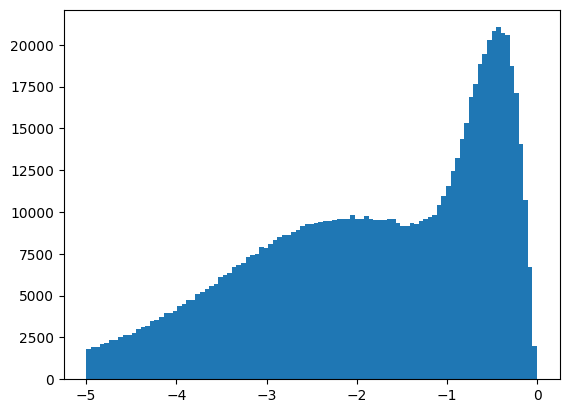

In [25]:

score,dists,hs_f = get_score_final(zxys_fs)

In [26]:
np.savez("D104_traces_info.npz",zxys_fs=zxys_fs,score=score,th67=[th6,th7])

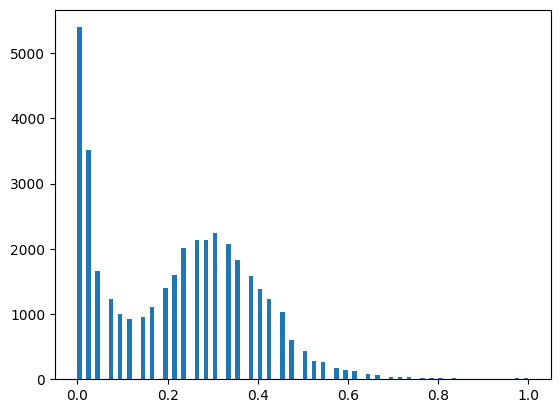

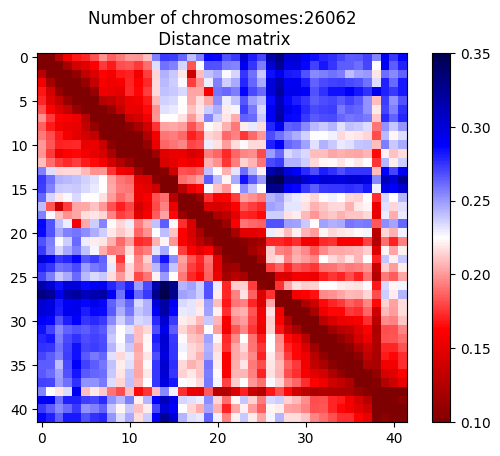

In [27]:
X = zxys_fs[:,:,:3].copy()
X[score<-1.25]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.hist(fr,bins=100);
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[fr>0.1]])
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

# Figure g

In [29]:
th6,th7

(11.721965521719671, 12.75)

C:\Users\carlos\AppData\Local\Temp\ipykernel_14708\633803309.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])


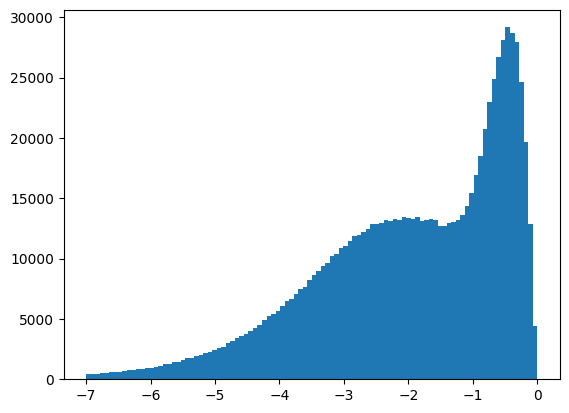

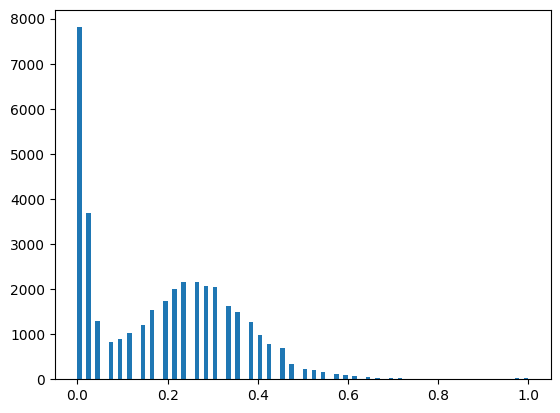

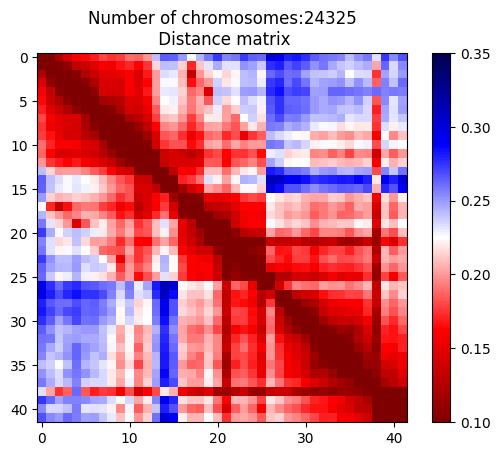

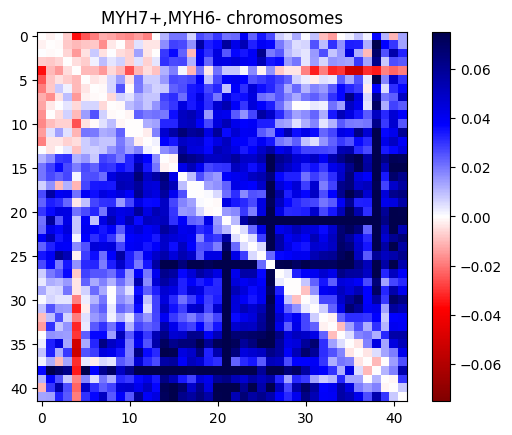

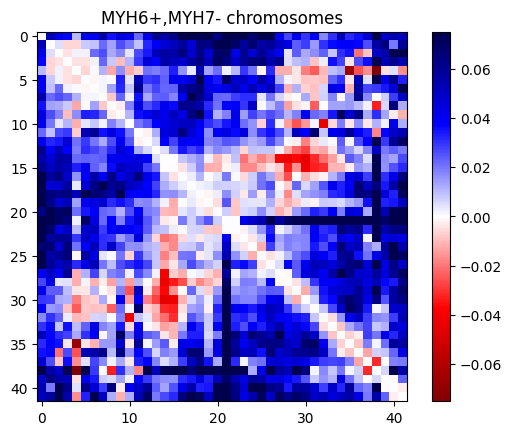

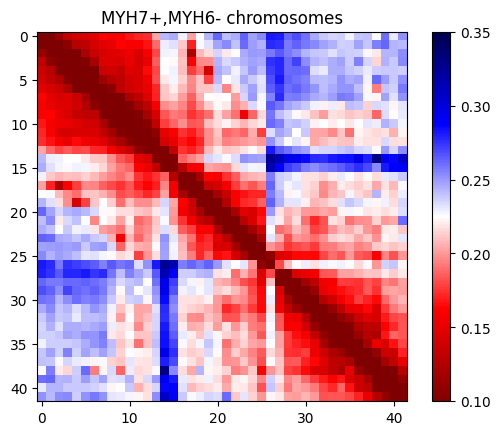

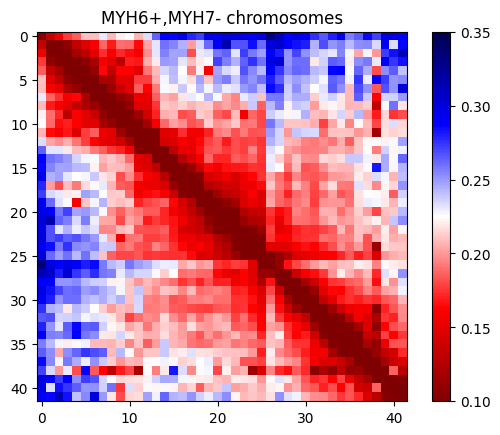

In [31]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D104_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D120 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("MYH7+,MYH6- chromosomes")
plt.imshow(np.nanmedian(mats[keep7],axis=0)-np.nanmedian(mats[keepN],axis=0),vmin=-0.075,vmax=0.075,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2g_7_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

plt.figure()
plt.title("MYH6+,MYH7- chromosomes")
plt.imshow(np.nanmedian(mats[keep6],axis=0)-np.nanmedian(mats[keepN],axis=0),vmin=-0.075,vmax=0.075,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2g_6_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

plt.figure()
plt.title("MYH7+,MYH6- chromosomes")
plt.imshow(np.nanmedian(mats[keep7],axis=0),vmin=0.1,vmax=0.35,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2gsupp_7_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

plt.figure()
plt.title("MYH6+,MYH7- chromosomes")
plt.imshow(np.nanmedian(mats[keep6],axis=0),vmin=0.1,vmax=0.35,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2gsupp_6_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

C:\Users\Carlos\AppData\Local\Temp\ipykernel_12900\2213552047.py:1: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[fr>0.1,0,-1]),np.log(zxys_fs[fr>0.1,0,-2])


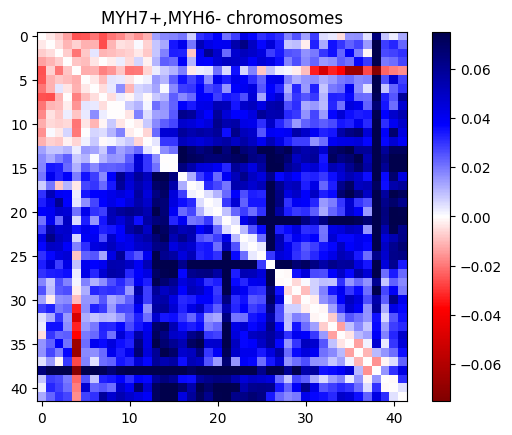

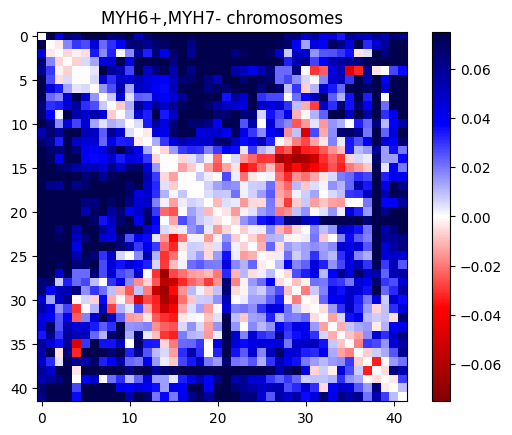

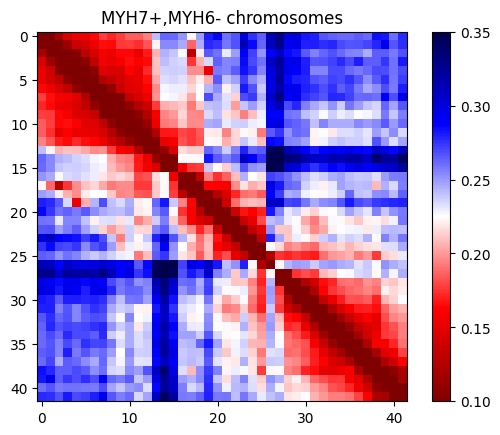

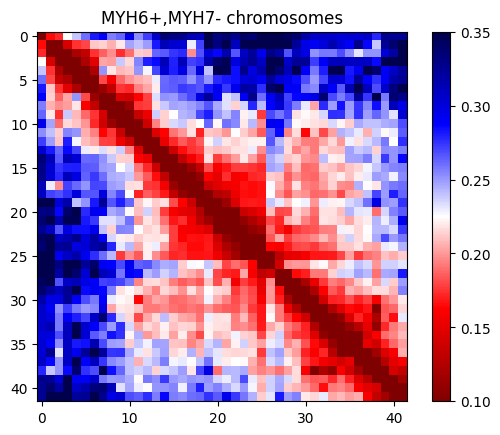

In [55]:
H7,H6 = np.log(zxys_fs[fr>0.1,0,-1]),np.log(zxys_fs[fr>0.1,0,-2])
#th6,th7 = 11.721965521719671,12.75
th6,th7 = 12.5,12.75
np.sum(H7>th7),np.sum(H6>th6),np.sum((H7>th7)&(H6>th6))#&(zxys_fs[fr>0.1,0,-2]<th6))
icells_mats = zxys_fs[fr>0.1,0,-3]
keep7 = (H7>th7)&(H6<th6)#&np.in1d(icells_mats,icells_CMS)
keep6 = (H6>th6)&(H7<th7)#&np.in1d(icells_mats,icells_CMS)
keepN = (H6<th6)&(H7<th7)
plt.figure()
plt.title("MYH7+,MYH6- chromosomes")
plt.imshow(np.nanmedian(mats[keep7],axis=0)-np.nanmedian(mats[keepN],axis=0),vmin=-0.075,vmax=0.075,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2g_7_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

plt.figure()
plt.title("MYH6+,MYH7- chromosomes")
plt.imshow(np.nanmedian(mats[keep6],axis=0)-np.nanmedian(mats[keepN],axis=0),vmin=-0.075,vmax=0.075,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2g_6_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

plt.figure()
plt.title("MYH7+,MYH6- chromosomes")
plt.imshow(np.nanmedian(mats[keep7],axis=0),vmin=0.1,vmax=0.35,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2gsupp_7_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

plt.figure()
plt.title("MYH6+,MYH7- chromosomes")
plt.imshow(np.nanmedian(mats[keep6],axis=0),vmin=0.1,vmax=0.35,cmap='seismic_r')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2gsupp_6_D80.pdf", format='pdf', bbox_inches='tight')
plt.colorbar()

In [32]:
def get_random_maps(mats,iDNA7_,N=100,dth=0.1):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)
def get_random_maps_med(mats,iDNA7_,N=100):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.nanmedian(mats[iDNA7_[iRand]],axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)
is7f_ = np.where(keep7)[0]
is6f_ = np.where(keep6)[0]
isnone = np.where(keepN)[0]
len(is7f_),len(is6f_),len(isnone)
#med_6s = get_random_maps(mats,is6f_,N=100)
#med_7s = get_random_maps(mats,is7f_,N=100)
med_7_Cs = get_random_maps(mats,is7f_)
med_6_Cs = get_random_maps(mats,is6f_)

 31%|█████████████████████████                                                        | 31/100 [00:00<00:01, 36.70it/s]C:\Users\carlos\AppData\Local\Temp\ipykernel_14708\3254749939.py:5: RuntimeWarning: invalid value encountered in divide
  med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 37.20it/s]


In [33]:
med_6s = get_random_maps_med(mats,is6f_,N=100)
med_7s = get_random_maps_med(mats,is7f_,N=100)
med_Ns = get_random_maps_med(mats,isnone,N=100)

  3%|██▍                                                                               | 3/100 [00:00<00:09,  9.77it/s]C:\Users\carlos\anaconda3\envs\cellpose2\lib\site-packages\numpy\lib\nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.23it/s]


# Figure i

Region 13-28: p = 2.52e-34


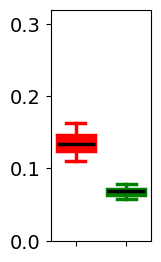

Region 13-31: p = 4.95e-33


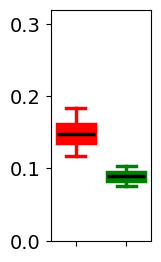

Region 27-31: p = 1.62e-07


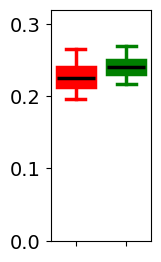

In [41]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

for i1, i2 in [[13, 28], [13, 31], [27, 31]]:
    X, Y = med_6_Cs[:, i1, i2], med_7_Cs[:, i1, i2]

    # Remove NaNs
    X_clean = X[~np.isnan(X)]
    Y_clean = Y[~np.isnan(Y)]

    # Compute p-value
    stat, pval = ranksums(X_clean, Y_clean)
    print(f"Region {i1}-{i2}: p = {pval:.2e}")

    # Plotting
    plt.rcParams.update({'font.size': 14})
    fig, ax = plt.subplots(figsize=(1.3, 3))  # slightly wider for aesthetics
    line_width = 2.5

    ax.boxplot(X_clean, positions=[0], patch_artist=True,
               boxprops=dict(facecolor='red', color='red', linewidth=line_width),
               whiskerprops=dict(color='red', linewidth=line_width),
               capprops=dict(color='red', linewidth=line_width),
               medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

    ax.boxplot(Y_clean, positions=[0.2], patch_artist=True,
               boxprops=dict(facecolor='green', color='green', linewidth=line_width),
               whiskerprops=dict(color='green', linewidth=line_width),
               capprops=dict(color='green', linewidth=line_width),
               medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

    ax.set_ylim(0., 0.32)
    ax.set_xticks([0, 0.2])
    ax.set_xticklabels(['', ''])
    ax.set_xlim([-0.1, 0.3])

    # Save figure
    plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2h_{i1}_{i2}_D80.pdf", format='pdf', bbox_inches='tight')
    plt.show()

In [43]:
import numpy as np
from tqdm import tqdm

def get_random_med(mats, iDNA7_, N=100):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        # sample with replacement
        iRand = np.random.randint(0, len(iDNA7_), len(iDNA7_))
        # take subset and compute nanmedian along axis=0
        med_7_C = np.nanmedian(mats[iDNA7_[iRand]], axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

phy_7 = get_random_med(mats,is7f_)
phy_6 = get_random_med(mats,is6f_)

 24%|███████████████████▍                                                             | 24/100 [00:02<00:07,  9.68it/s]C:\Users\carlos\anaconda3\envs\cellpose2\lib\site-packages\numpy\lib\nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:10<00:00,  9.61it/s]


Region 13-28: p = 2.52e-34


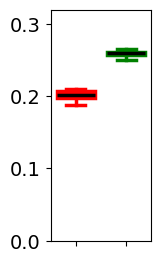

Region 13-31: p = 2.52e-34


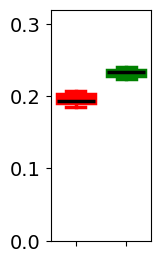

Region 27-31: p = 3.95e-09


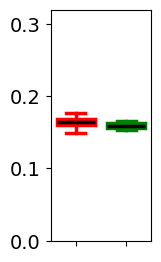

In [44]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

for i1, i2 in [[13, 28], [13, 31], [27, 31]]:
    X, Y = phy_6[:, i1, i2], phy_7[:, i1, i2]

    # Remove NaNs
    X_clean = X[~np.isnan(X)]
    Y_clean = Y[~np.isnan(Y)]

    # Compute p-value
    stat, pval = ranksums(X_clean, Y_clean)
    print(f"Region {i1}-{i2}: p = {pval:.2e}")

    # Plotting
    plt.rcParams.update({'font.size': 14})
    fig, ax = plt.subplots(figsize=(1.3, 3))  # slightly wider for aesthetics
    line_width = 2.5

    ax.boxplot(X_clean, positions=[0], patch_artist=True,
               boxprops=dict(facecolor='red', color='red', linewidth=line_width),
               whiskerprops=dict(color='red', linewidth=line_width),
               capprops=dict(color='red', linewidth=line_width),
               medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

    ax.boxplot(Y_clean, positions=[0.2], patch_artist=True,
               boxprops=dict(facecolor='green', color='green', linewidth=line_width),
               whiskerprops=dict(color='green', linewidth=line_width),
               capprops=dict(color='green', linewidth=line_width),
               medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

    ax.set_ylim(0., 0.32)
    ax.set_xticks([0, 0.2])
    ax.set_xticklabels(['', ''])
    ax.set_xlim([-0.1, 0.3])

    # Save figure
    plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2h_{i1}_{i2}_D80_dis.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# Figure h

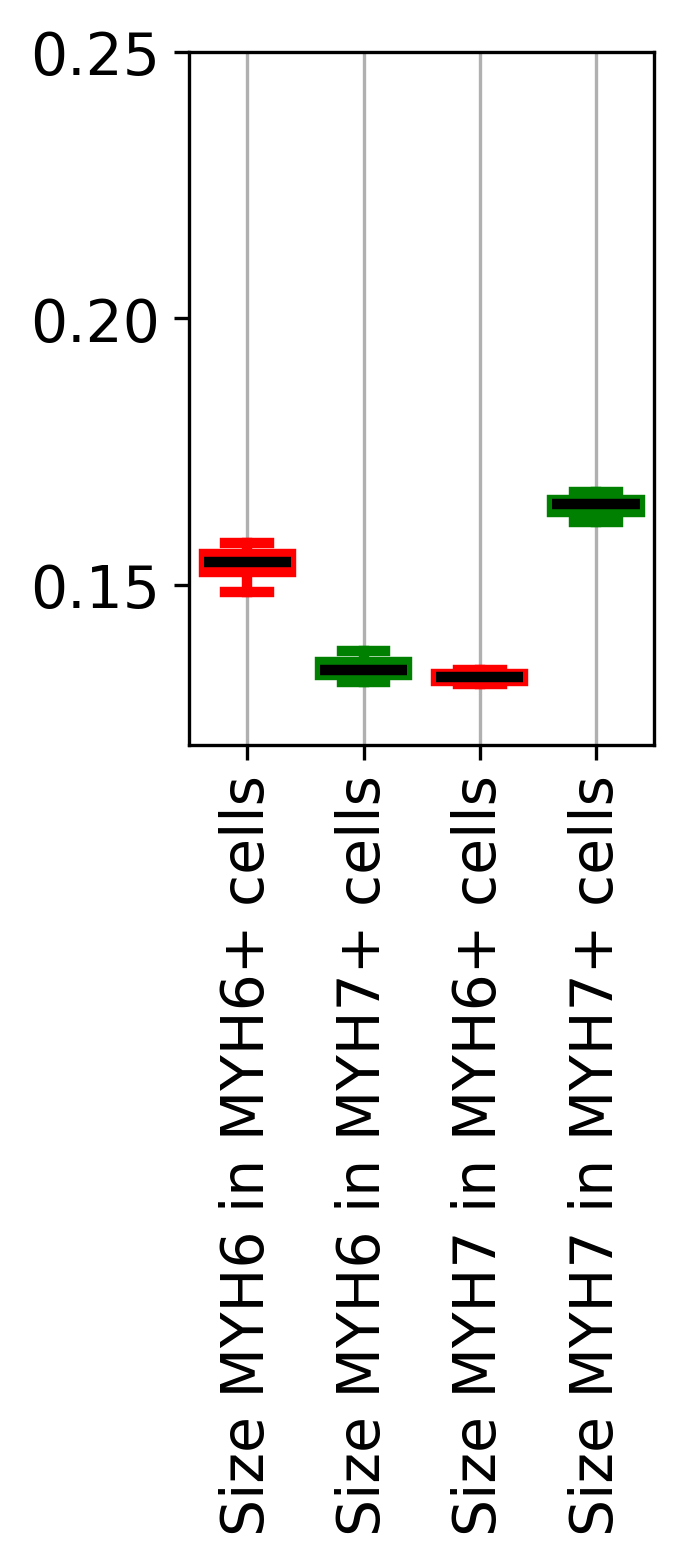

In [42]:

i1s,i2s = zip(*[(i1,i2)for i1 in np.arange(0,13+1) for i2 in np.arange(0,13+1) if i1>i2])
sizeN_m6 = np.mean(med_Ns[:,i1s,i2s],axis=-1)
size7_m6 = np.mean(med_7s[:,i1s,i2s],axis=-1)
size6_m6 = np.mean(med_6s[:,i1s,i2s],axis=-1)

i1s,i2s = zip(*[(i1,i2)for i1 in np.arange(17,27+1) for i2 in np.arange(17,27+1) if i1>i2])

sizeN_m7 = np.mean(med_Ns[:,i1s,i2s],axis=-1)
size7_m7 = np.mean(med_7s[:,i1s,i2s],axis=-1)
size6_m7 = np.mean(med_6s[:,i1s,i2s],axis=-1)

import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(2,3),dpi=300)

# Box plot for X in red
line_width = 2.5
for p,col,vals in [(0,'red',size6_m6),(0.4,'red',size7_m6)]+[(0.2,'green',size6_m7),(0.6,'green',size7_m7)]:
    box_X = ax.boxplot(vals, positions=[p], patch_artist=True, 
                       boxprops=dict(facecolor=col, color=col,linewidth=line_width),
                       whiskerprops=dict(color=col,linewidth=line_width),
                       capprops=dict(color=col,linewidth=line_width),
                       medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Set y-axis limits
ax.set_ylim(0.12, 0.25)

# Set labels and title
ax.set_xticks([0, 0.2,0.4,0.6])
ax.set_xticklabels([])
ax.set_xlim([-0.1,.7])
#ax.set_title('Region:'+str([i1,i2]))
plt.grid(axis='x')
plt.xticks([0, 0.2,0.4,0.6],['Size MYH6 in MYH6+ cells','Size MYH6 in MYH7+ cells','Size MYH7 in MYH6+ cells','Size MYH7 in MYH7+ cells'],rotation='vertical')
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2i_D80.pdf", format='pdf', bbox_inches='tight')
# Show plot
plt.show()

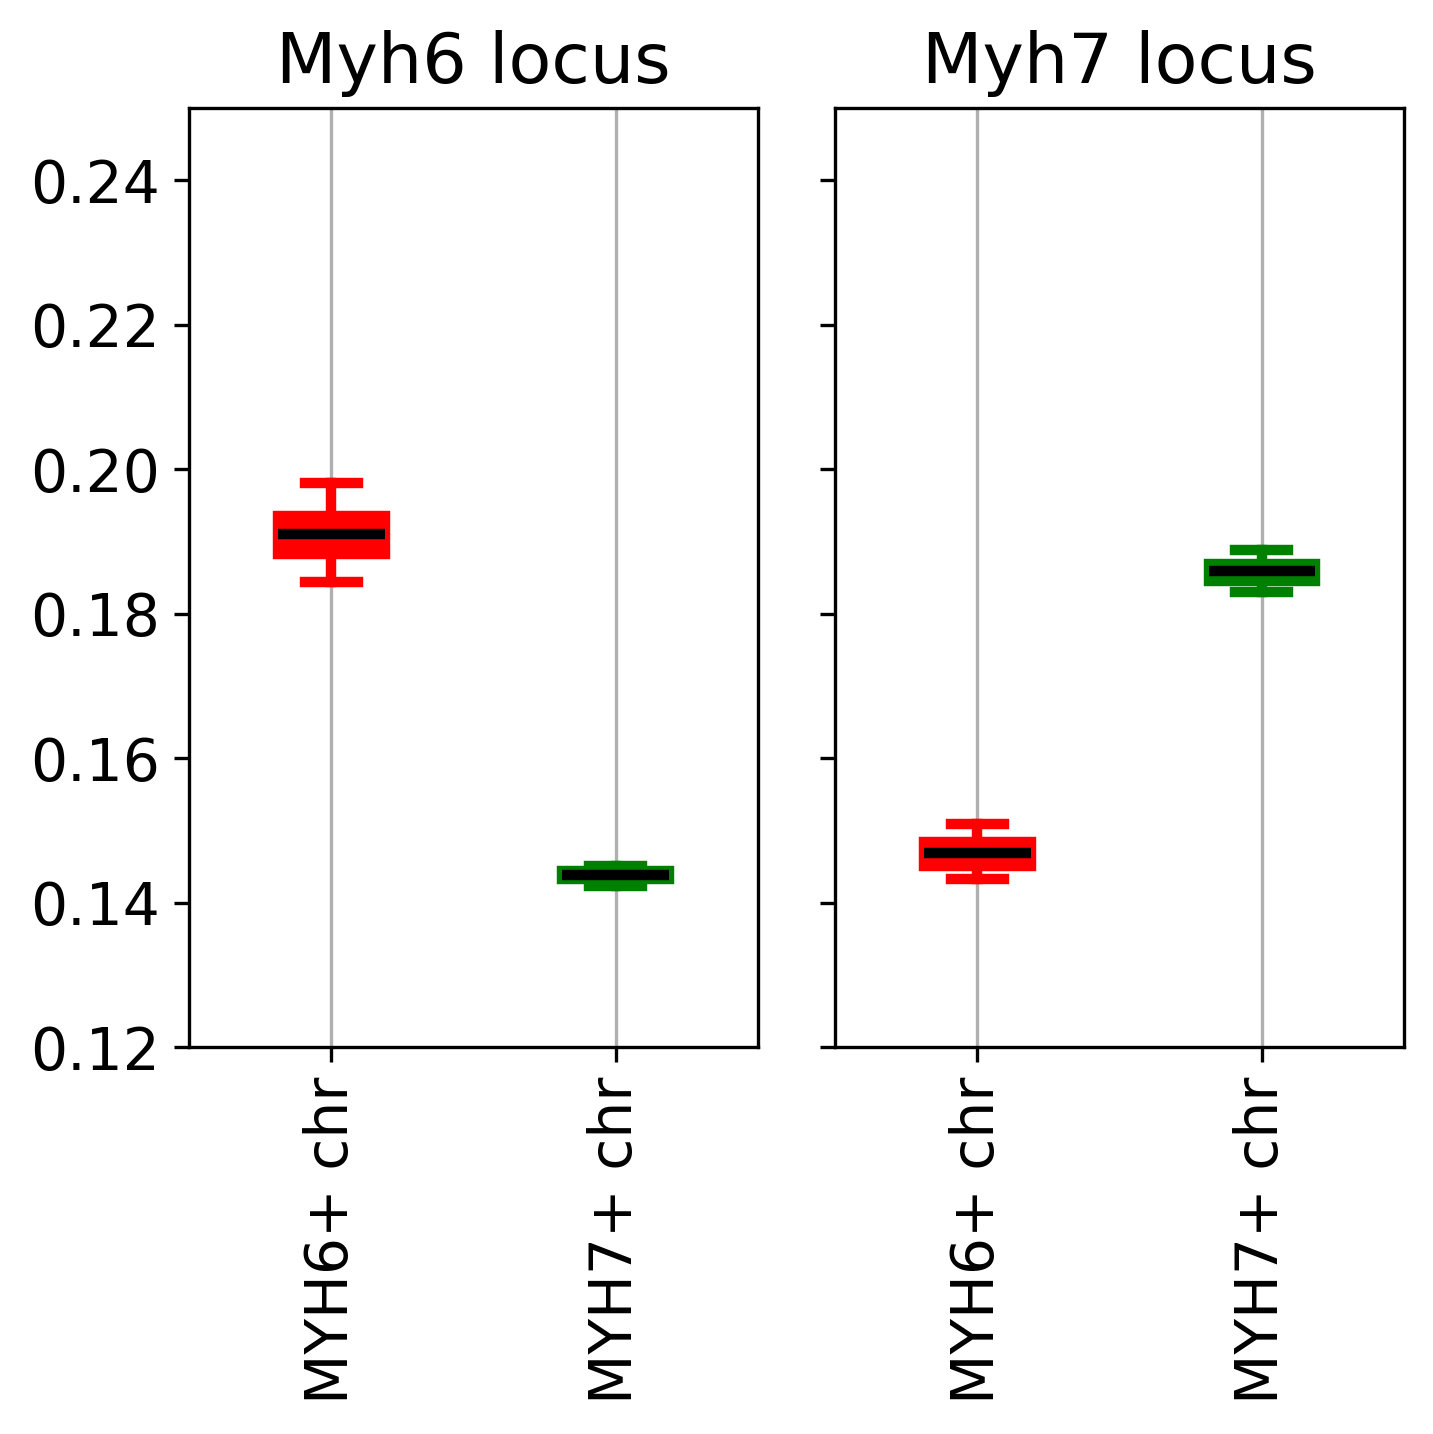

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Get i1,i2 pairs for left region (0–13)
i1s_left, i2s_left = zip(*[(i1,i2) for i1 in np.arange(0,14) for i2 in np.arange(0,14) if i1 > i2])
sizeN_m6 = np.mean(med_Ns[:,i1s_left,i2s_left], axis=-1)
size7_m6 = np.mean(med_7s[:,i1s_left,i2s_left], axis=-1)
size6_m6 = np.mean(med_6s[:,i1s_left,i2s_left], axis=-1)

# Get i1,i2 pairs for right region (17–27)
i1s_right, i2s_right = zip(*[(i1,i2) for i1 in np.arange(17,28) for i2 in np.arange(17,28) if i1 > i2])
sizeN_m7 = np.mean(med_Ns[:,i1s_right,i2s_right], axis=-1)
size7_m7 = np.mean(med_7s[:,i1s_right,i2s_right], axis=-1)
size6_m7 = np.mean(med_6s[:,i1s_right,i2s_right], axis=-1)

# Plotting
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(1, 2, figsize=(5, 5), dpi=300, sharey=True)

for p, col, vals in [(0, 'red', size6_m6), (0.4, 'green', size7_m6)]:
    axs[0].boxplot(vals, positions=[p], patch_artist=True,
                   boxprops=dict(facecolor=col, color=col, linewidth=2.5),
                   whiskerprops=dict(color=col, linewidth=2.5),
                   capprops=dict(color=col, linewidth=2.5),
                   medianprops=dict(color='k', linewidth=2.5), whis=[5, 95], showfliers=False)
axs[0].set_title("Myh6 locus")
axs[0].set_xticks([0, 0.4])
axs[0].set_xticklabels(['MYH6+ chr', 'MYH7+ chr'], rotation='vertical')
axs[0].grid(axis='x')
axs[0].set_xlim([-0.2, 0.6])

# Plot for Right Half (17–27)
for p, col, vals in [(0, 'red', size6_m7), (0.4, 'green', size7_m7)]:
    axs[1].boxplot(vals, positions=[p], patch_artist=True,
                   boxprops=dict(facecolor=col, color=col, linewidth=2.5),
                   whiskerprops=dict(color=col, linewidth=2.5),
                   capprops=dict(color=col, linewidth=2.5),
                   medianprops=dict(color='k', linewidth=2.5), whis=[5, 95], showfliers=False)
axs[1].set_title("Myh7 locus")
axs[1].set_xticks([0, 0.4])
axs[1].set_xticklabels(['MYH6+ chr', 'MYH7+ chr'], rotation='vertical')
axs[1].grid(axis='x')
axs[1].set_xlim([-0.2, 0.6])

# Common y-axis limits
axs[0].set_ylim(0.12, 0.25)

# Save and show
plt.tight_layout()
plt.savefig(r"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure2i_D80_split.pdf", format='pdf', bbox_inches='tight')
plt.show()
